# t-SNE for Non-linear Dimensionality Reduction and Visualization

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand t-SNE fundamentals and its use in non-linear dimensionality reduction
- Implement t-SNE in Python for data visualization
- Analyze properties and effectiveness of t-SNE
- Compare t-SNE with PCA and SVD for high-dimensional data analysis
- Apply t-SNE on real-world datasets including images and text data

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 2, lesson 06 "Developing Simple Supervised and Unsupervised Learning Models" — the iris clusters you could not plot in four dimensions; PCA straightens them linearly, t-SNE does not have to.

**Used later in:** Course 10 (AIAT 124) — Unit 1, lesson 12 "Exploring Latent Spaces and Interpolation" — inspecting a generative model's latent space needs exactly this.

---

This notebook covers practical activities from **Course 03, Unit 4**:
- Using t-SNE for visualizing high-dimensional data in 2D or 3D dimensions
- Comparing PCA, SVD, and t-SNE for different data analysis tasks
- Writing code to apply dimensionality reduction techniques on real-world datasets

---

## Introduction

**t-SNE (t-distributed Stochastic Neighbor Embedding)** is a non-linear dimensionality reduction technique that preserves local neighborhood structures, making it excellent for visualization.


---

## 📌 Real case: the article that had to be written because t-SNE plots were being misread

Laurens van der Maaten and Geoffrey Hinton introduced **t-SNE** in 2008 (JMLR 9, 2579–2605) and it became
the default way to show high-dimensional data — single-cell biology, word embeddings, neural-network
activations. Eight years later Martin Wattenberg, Fernanda Viégas and Ian Johnson published
**"How to Use t-SNE Effectively"** in *Distill* (2016), an interactive article whose entire purpose is to
stop people over-reading the pictures. Three of its findings, in their words:

- **"You cannot see relative sizes of clusters in a t-SNE plot"** — the algorithm "naturally expands dense
  clusters, and contracts sparse ones, evening out cluster sizes."
- **"Distances between well-separated clusters in a t-SNE plot may mean nothing."**
- Random, structureless data can be made to look convincingly clustered by choosing a low perplexity.

So the most persuasive visualisation in machine learning is one whose two most obvious visual cues — how
big a blob is, and how far apart two blobs are — are not to be trusted.

**What goes wrong without this.** A t-SNE plot is the single easiest figure to over-claim from. It looks
like a map, so people read distances off it. It is not a map; it is an arrangement that preserves *who is
near whom*, and deliberately sacrifices everything else to do so.


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# Setup: two REAL sklearn datasets (handwritten digits and iris flowers) and PCA,
# plus a guarded t-SNE import — the HAS_TSNE flag lets later cells degrade gracefully
# if the library is missing.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits, load_iris
from sklearn.decomposition import PCA

# Try importing t-SNE
try:
    from sklearn.manifold import TSNE
    HAS_TSNE = True
    print("✅ t-SNE available from sklearn.manifold")
except ImportError:
    HAS_TSNE = False
    print("⚠️  t-SNE not available. Install with: pip install scikit-learn")

# Confirm the environment is ready before any math starts.
print("✅ Libraries imported!")


✅ t-SNE available from sklearn.manifold
✅ Libraries imported!


## Part 1: Understanding t-SNE Fundamentals

t-SNE preserves local neighborhood structures in high-dimensional data.


In [2]:
# Orientation card: what t-SNE is good at (local structure, visualization) and what it costs
# (slow on big data, stochastic output) — keep these in mind when reading the plots below.

print("=" * 60)
print("t-SNE Fundamentals")
print("=" * 60)

print("\nKey Characteristics:")
print("  1. Non-linear dimensionality reduction")
print("  2. Preserves local neighborhood structures")
print("  3. Excellent for visualization (2D/3D)")
print("  4. Computationally expensive for large datasets")
print("  5. Stochastic - results vary with different random seeds")

print("\n✅ t-SNE is ideal for:")
print("  - Visualizing high-dimensional data")
print("  - Understanding data clusters and structure")
print("  - Exploratory data analysis")


t-SNE Fundamentals

Key Characteristics:
  1. Non-linear dimensionality reduction
  2. Preserves local neighborhood structures
  3. Excellent for visualization (2D/3D)
  4. Computationally expensive for large datasets
  5. Stochastic - results vary with different random seeds

✅ t-SNE is ideal for:
  - Visualizing high-dimensional data
  - Understanding data clusters and structure
  - Exploratory data analysis


## Part 2: Implementing t-SNE for Visualization


t-SNE Implementation
Dataset: sklearn digits - real scanned handwriting
Original data shape: (600, 64)  (600 images x 64 pixels)
Number of classes: 10 (the digits 0-9)

Applying t-SNE (this may take a moment)...


t-SNE reduced shape: (600, 2)
✅ t-SNE transformation complete!


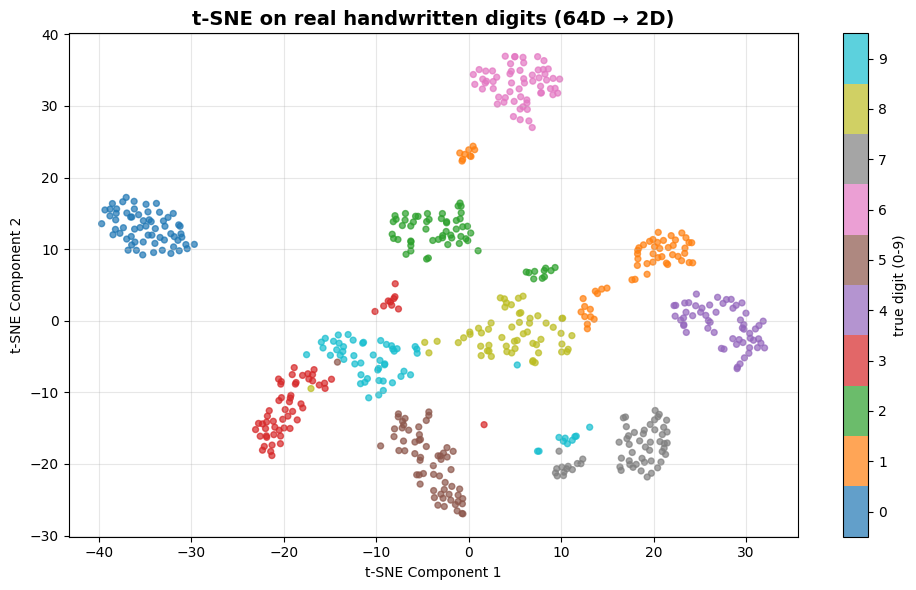


✅ t-SNE preserves local clusters in 2D visualization!

   Neighbourhood purity per digit (share of the 10 nearest neighbours
   in the 2D map that carry the same true label):
     digit 9: 89.0%
     digit 8: 91.9%
     digit 3: 93.2%
     digit 1: 94.3%
     digit 2: 98.4%
     digit 5: 98.4%
     digit 7: 98.5%
     digit 0: 100.0%
     digit 4: 100.0%
     digit 6: 100.0%

   Most-mixed digit pairs in this embedding: 8/9, 7/9, 1/8
   Real handwriting genuinely blurs those shapes. A synthetic blob dataset would
   have separated perfectly and taught you nothing about where t-SNE struggles.


In [3]:
# Run t-SNE on REAL 64-dimensional data and plot the 2D embedding.
# The ten handwritten digit classes should reappear as separate islands - local
# neighborhoods survive the crush from 64 dimensions down to 2.

if HAS_TSNE:
    # Real high-dimensional data: scanned handwritten digits, each an 8x8 image
    # flattened to 64 pixel intensities. We take the first 600 images to keep the
    # run fast; t-SNE is never told which digit is which.
    digits = load_digits()
    X, y = digits.data[:600], digits.target[:600]
    
    print("=" * 60)
    print("t-SNE Implementation")
    print("=" * 60)
    print("Dataset: sklearn digits - real scanned handwriting")
    print(f"Original data shape: {X.shape}  (600 images x 64 pixels)")
    print(f"Number of classes: {len(np.unique(y))} (the digits 0-9)")
    
    # Apply t-SNE
    print("\nApplying t-SNE (this may take a moment)...")
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    X_tsne = tsne.fit_transform(X)
    
    print(f"t-SNE reduced shape: {X_tsne.shape}")
    print("✅ t-SNE transformation complete!")
    
    # Visualize
    plt.figure(figsize=(10, 6))
    # tab10 is a CATEGORICAL palette - a digit label is a class, not a quantity, and the
    # same palette is reused in the storyboard below so the two figures can be compared.
    scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='tab10', alpha=0.7, s=18)
    scatter.set_clim(-0.5, 9.5)
    plt.colorbar(scatter, ticks=range(10), label='true digit (0-9)')
    plt.title('t-SNE on real handwritten digits (64D → 2D)', fontsize=14, fontweight='bold')
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print("\n✅ t-SNE preserves local clusters in 2D visualization!")

    # Measure the claim instead of asserting it: for every point, how many of its 10
    # nearest neighbours IN THE EMBEDDING carry the same true digit label?
    from sklearn.neighbors import NearestNeighbors
    from collections import Counter

    neighbours = NearestNeighbors(n_neighbors=11).fit(X_tsne)
    _, nbr_idx = neighbours.kneighbors(X_tsne)
    nbr_idx = nbr_idx[:, 1:]  # drop each point itself

    purity = {int(c): float(np.mean(y[nbr_idx[y == c]] == c)) for c in np.unique(y)}
    confusions = Counter()
    for i in range(len(y)):
        for j in nbr_idx[i]:
            if y[j] != y[i]:
                confusions[tuple(sorted((int(y[i]), int(y[j]))))] += 1

    print("\n   Neighbourhood purity per digit (share of the 10 nearest neighbours")
    print("   in the 2D map that carry the same true label):")
    for digit in sorted(purity, key=purity.get):
        print(f"     digit {digit}: {purity[digit]:.1%}")
    worst = ", ".join(f"{a}/{b}" for (a, b), _ in confusions.most_common(3))
    print(f"\n   Most-mixed digit pairs in this embedding: {worst}")
    print("   Real handwriting genuinely blurs those shapes. A synthetic blob dataset would")
    print("   have separated perfectly and taught you nothing about where t-SNE struggles.")
else:
    print("=" * 60)
    print("t-SNE Implementation (Installation Required)")
    print("=" * 60)
    print("""
    To use t-SNE:
    
    1. Install scikit-learn:
       pip install scikit-learn
    
    2. Import and use:
       from sklearn.manifold import TSNE
       
       tsne = TSNE(n_components=2, random_state=42, perplexity=30)
       X_tsne = tsne.fit_transform(X)
    
    3. Parameters:
       - n_components: Output dimensions (2 or 3 for visualization)
       - perplexity: Balance between local and global structure (typically 30-50)
       - random_state: For reproducible results
    """)


**Read the figure above.** 600 real handwritten digits, each originally 64 pixel
intensities, placed on a page by t-SNE (perplexity 30, seed 42). The ten colours land in ten mostly
separate islands, and t-SNE was never told which digit is which — the labels are only the colouring. But
resist reading the picture further than it goes. The only claim it supports is the local one printed
underneath: **neighbourhood purity**, the share of each point's ten nearest neighbours in this map carrying
the same true digit. Those numbers run from **100% for digits 0, 4 and 6** down to **89.0% for digit 9**,
and the most-mixed pairs are **8/9, 7/9 and 1/8** — pairs a person's handwriting genuinely confuses. What
the picture does *not* support: how big an island is, how far apart two islands sit, or which island is
next to which. The storyboard below shows why.


Running six t-SNE embeddings of the same 600 images...


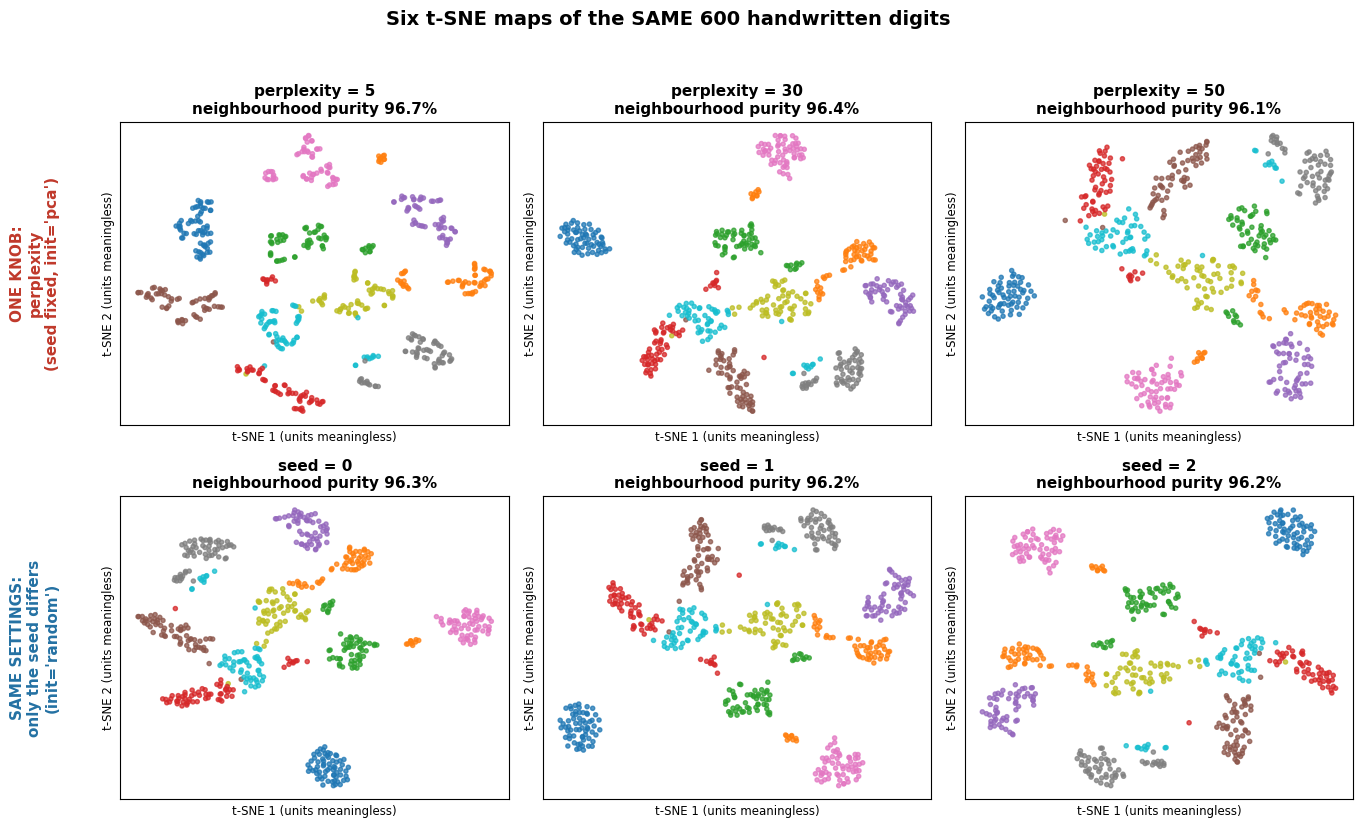


Read the storyboard: every panel contains the same 600 images with the same colours.
Top row, only perplexity changes: at 5 the digits shatter into many small shards; at 30
and 50 they consolidate into fewer, rounder islands. Bottom row, nothing changes but the
random seed: the islands are the same islands, but they are rotated and rearranged, so
their positions relative to each other are not a finding. Now compare the purity numbers
in the titles - all six sit between 96.1% and 96.7%. The picture moves a lot;
the one quantity it licenses barely does. That gap is why you report the number.


In [4]:
# STORYBOARD: the two warnings this notebook prints - "perplexity changes the picture" and
# "t-SNE is stochastic" - are claims about how the map MOVES, and no single map can show that.
# So run t-SNE six times on the same 600 real digit images and lay the frames out in a grid.
# Every panel plots the same points with the same colours; only the setting changes.
if HAS_TSNE:
    from sklearn.neighbors import NearestNeighbors

    def purity_of(embedding, labels, n_neighbors=10):
        """Share of each point's nearest neighbours IN THE MAP that carry the same true digit.
        This is the only kind of claim a t-SNE picture supports: a local one."""
        idx = NearestNeighbors(n_neighbors=n_neighbors + 1).fit(embedding).kneighbors(
            embedding, return_distance=False)[:, 1:]
        return float(np.mean(labels[idx] == labels[:, None]))

    # Row 1: turn ONE knob (perplexity). Row 2: change ONLY the random seed, with the
    # old random initialisation that makes t-SNE's stochasticity visible.
    row1 = [("perplexity = 5", dict(perplexity=5, random_state=42, init="pca")),
            ("perplexity = 30", dict(perplexity=30, random_state=42, init="pca")),
            ("perplexity = 50", dict(perplexity=50, random_state=42, init="pca"))]
    row2 = [(f"seed = {sd}", dict(perplexity=30, random_state=sd, init="random"))
            for sd in (0, 1, 2)]

    fig, axes = plt.subplots(2, 3, figsize=(14, 8.4))
    print("\nRunning six t-SNE embeddings of the same 600 images...")
    for r, row in enumerate((row1, row2)):
        for col, (title, kwargs) in enumerate(row):
            emb = TSNE(n_components=2, **kwargs).fit_transform(X)
            ax = axes[r, col]
            ax.scatter(emb[:, 0], emb[:, 1], c=y, cmap="tab10", s=9, alpha=0.75)
            ax.set_title(f"{title}\nneighbourhood purity {purity_of(emb, y):.1%}",
                         fontsize=11, fontweight="bold")
            ax.set_xticks([]); ax.set_yticks([])   # t-SNE axis VALUES mean nothing - do not invite reading them
            ax.set_xlabel("t-SNE 1 (units meaningless)", fontsize=8.5)
            ax.set_ylabel("t-SNE 2 (units meaningless)", fontsize=8.5)

    axes[0, 0].text(-0.22, 0.5, "ONE KNOB:\nperplexity\n(seed fixed, init='pca')",
                    transform=axes[0, 0].transAxes, rotation=90, va="center", ha="center",
                    fontsize=11, fontweight="bold", color="#c0392b")
    axes[1, 0].text(-0.22, 0.5, "SAME SETTINGS:\nonly the seed differs\n(init='random')",
                    transform=axes[1, 0].transAxes, rotation=90, va="center", ha="center",
                    fontsize=11, fontweight="bold", color="#2471a3")
    fig.suptitle("Six t-SNE maps of the SAME 600 handwritten digits", fontsize=14, fontweight="bold")
    plt.tight_layout(rect=(0.03, 0, 1, 0.95))
    plt.show()

    print("\nRead the storyboard: every panel contains the same 600 images with the same colours.")
    print("Top row, only perplexity changes: at 5 the digits shatter into many small shards; at 30")
    print("and 50 they consolidate into fewer, rounder islands. Bottom row, nothing changes but the")
    print("random seed: the islands are the same islands, but they are rotated and rearranged, so")
    print("their positions relative to each other are not a finding. Now compare the purity numbers")
    print("in the titles - all six sit between 96.1% and 96.7%. The picture moves a lot;")
    print("the one quantity it licenses barely does. That gap is why you report the number.")
else:
    print("Install scikit-learn to run the perplexity / seed storyboard.")


**Read the storyboard above.** Six t-SNE maps of the *same* 600 digit images, same colours
throughout, one setting changed at a time. The **top-middle panel is the same embedding as the map above**
— perplexity 30, seed 42 — so use it as your reference point.

**Top row — one knob, perplexity.** At **perplexity 5** the digits shatter: brown, pink and orange each
break into two or three separate shards, and the map has roughly twice as many islands as there are digits.
At **30** and **50** those shards fuse into fewer, rounder, larger blobs. Nothing about the data changed.
If you had read "how many clusters are there?" off the perplexity-5 panel, you would have been wrong, and
the panel would have looked just as convincing.

**Bottom row — nothing changed but the random seed.** These are the same islands every time, but they are
rotated and rearranged: the blue 0s sit at the bottom for seed 0, bottom-left for seed 1, top-right for
seed 2. So *where* a cluster is, and *which* cluster it sits next to, are not findings. They are leftovers
from the initialisation. (These three use `init='random'`, which makes the effect plain; scikit-learn now
defaults to `init='pca'`, which stabilises the global layout but does not make inter-cluster distances
meaningful.)

**Now read the six titles.** Neighbourhood purity — the share of each point's ten nearest neighbours in the
map that carry the same true digit — is **96.7%, 96.4%, 96.1%, 96.3%, 96.2%, 96.2%**. Six pictures that
look substantially different, and the one quantity they license moves by six-tenths of a percentage point.
That is the whole argument for reporting the number instead of describing the picture.

## Part 3: Comparing PCA, SVD, and t-SNE


Comparing PCA, SVD, and t-SNE
Dataset: Iris (4 features, 3 classes)


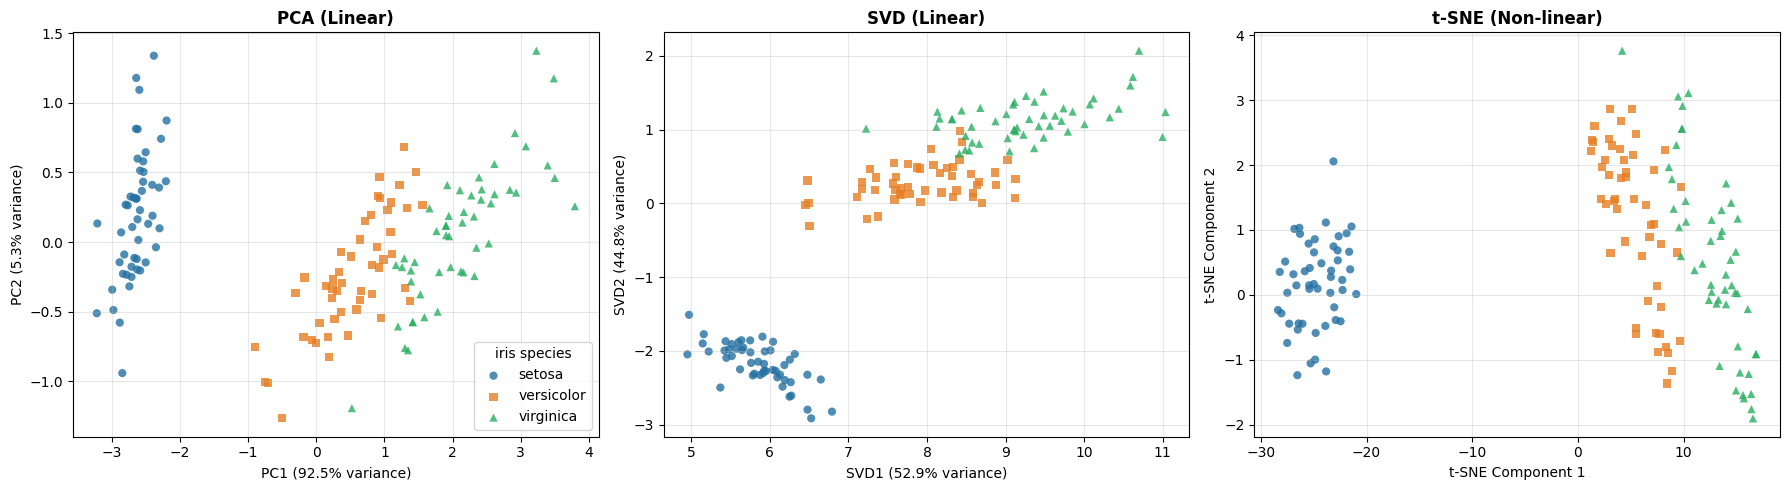


✅ Comparison Results:
  - PCA/SVD: Linear, preserves global structure, fast
  - t-SNE: Non-linear, preserves local neighborhoods, slower
  - Use PCA/SVD for dimensionality reduction and compression
  - Use t-SNE for visualization and exploratory analysis


In [5]:
# Same data, three lenses: PCA and SVD (linear) versus t-SNE (non-linear) on Iris.
# Comparing them side by side shows what 'preserving local structure' buys you.

if HAS_TSNE:
    # Load Iris dataset for comparison
    iris = load_iris()
    X_iris, y_iris = iris.data, iris.target
    
    print("=" * 60)
    print("Comparing PCA, SVD, and t-SNE")
    print("=" * 60)
    print(f"Dataset: Iris (4 features, 3 classes)")
    
    # PCA
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_iris)
    
    # SVD (TruncatedSVD)
    from sklearn.decomposition import TruncatedSVD
    svd = TruncatedSVD(n_components=2)
    X_svd = svd.fit_transform(X_iris)
    
    # t-SNE
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    X_tsne = tsne.fit_transform(X_iris)
    
    # Visualize all three. One colour and one marker per SPECIES, with a named legend -
    # 'category 0.5' is not a thing, so a continuous colour scale would have been wrong here.
    species_style = [(0, iris.target_names[0], '#2471a3', 'o'),
                     (1, iris.target_names[1], '#e67e22', 's'),
                     (2, iris.target_names[2], '#27ae60', '^')]
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    def draw_species(ax, Z):
        for code, name, colour, marker in species_style:
            m = y_iris == code
            ax.scatter(Z[m, 0], Z[m, 1], c=colour, marker=marker, s=35, alpha=0.8,
                       edgecolors='none', label=name)
    
    # PCA
    draw_species(axes[0], X_pca)
    axes[0].set_title('PCA (Linear)', fontsize=12, fontweight='bold')
    axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
    axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
    axes[0].grid(True, alpha=0.3)
    
    # SVD
    draw_species(axes[1], X_svd)
    axes[1].set_title('SVD (Linear)', fontsize=12, fontweight='bold')
    axes[1].set_xlabel(f'SVD1 ({svd.explained_variance_ratio_[0]:.1%} variance)')
    axes[1].set_ylabel(f'SVD2 ({svd.explained_variance_ratio_[1]:.1%} variance)')
    axes[1].grid(True, alpha=0.3)
    
    # t-SNE
    draw_species(axes[2], X_tsne)
    axes[2].set_title('t-SNE (Non-linear)', fontsize=12, fontweight='bold')
    axes[2].set_xlabel('t-SNE Component 1')
    axes[2].set_ylabel('t-SNE Component 2')
    axes[2].grid(True, alpha=0.3)
    axes[0].legend(title='iris species', fontsize=10, loc='best')
    
    plt.tight_layout()
    plt.show()
    
    print("\n✅ Comparison Results:")
    print("  - PCA/SVD: Linear, preserves global structure, fast")
    print("  - t-SNE: Non-linear, preserves local neighborhoods, slower")
    print("  - Use PCA/SVD for dimensionality reduction and compression")
    print("  - Use t-SNE for visualization and exploratory analysis")
else:
    print("Note: Install scikit-learn to compare PCA, SVD, and t-SNE")


**Read the figure above.** The same 150 iris flowers, four measurements each, through three
lenses; one colour and marker per species, named in the legend.

**PCA and SVD (left, middle) draw the same arrangement** — *setosa* (blue circles) alone on the left, then
*versicolor* (orange squares) and *virginica* (green triangles) side by side and touching along a boundary.
The middle panel is the left one flipped vertically, which is all that "the sign of a component is
arbitrary" means. Two differences worth noticing: both axes carry a meaningful **"% variance"** label, and
the SVD axes start at **5, not 0**, because `TruncatedSVD` did not subtract the mean — same shape, shifted
origin.

**t-SNE (right) does not make the problem easier than it is.** It opens a *wide* gap around setosa, far
wider than PCA's. But versicolor and virginica stay one connected mass with green wrapped around orange —
because in the measurements those two species genuinely overlap, and no projection can invent a gap that
the data does not contain. Note also the panel's shape: it is stretched flat, because t-SNE's coordinates
have no fixed scale and no variance to report. Wider gaps are not more separation.

---

## ⚠️ Where this breaks

- **Cluster sizes and inter-cluster distances are artefacts.** Per Wattenberg, Viégas and Johnson (2016),
  cited in this notebook's references: t-SNE expands dense clusters and contracts sparse ones, so a big
  blob is not a common class; and the gaps between separated blobs carry no reliable information. What the
  plot *does* support is the number printed below it — **neighbourhood purity**, the share of each point's
  ten nearest neighbours in the 2D map that carry the same true label. That is a local claim, which is the
  only kind t-SNE licenses.
- **Read the purity numbers, not the picture.** They run from 100% (digits 0, 4, 6) down to **89.0% for
  digit 9**, with the most-mixed pairs being 8/9, 7/9 and 1/8. Real handwriting genuinely blurs those
  shapes. A synthetic blob dataset would have separated perfectly and taught you nothing about where t-SNE
  struggles.
- **t-SNE is stochastic and has no `transform`.** Run it twice with different seeds and you get different
  pictures of the same data. Worse, scikit-learn's `TSNE` has no way to embed a new point into an existing
  map — you must re-run the whole thing. So t-SNE is an exploratory tool, not a preprocessing step: never
  put it in front of a classifier the way you would put PCA there.
- **It is slow and it scales badly.** This notebook uses 600 of the 1,797 digits precisely to keep the run
  short. Cheaper alternatives: reduce to ~50 dimensions with PCA first and run t-SNE on that (standard
  practice), or use UMAP (McInnes, Healy & Melville 2018, in the references), which is faster and does
  offer a `transform` — while inheriting the same warnings about reading sizes and distances.


---

## 💬 Discuss

1. If cluster sizes and inter-cluster distances in a t-SNE plot cannot be trusted, what *can* you honestly
   claim from one? Write the caption you would put under the digits figure in a report.
2. The most-mixed digit pairs are 8/9, 7/9 and 1/8 — shapes that genuinely resemble each other. Does that
   agreement with human intuition validate t-SNE, or is it a coincidence you should not lean on? Argue it.
3. A colleague shows you a t-SNE plot of customer data with two beautiful separated clusters and proposes
   a two-segment marketing strategy. List, in order, the questions you would ask before agreeing.


## Summary

### Key Concepts:
1. **t-SNE**: t-distributed Stochastic Neighbor Embedding
   - Non-linear dimensionality reduction
   - Preserves local neighborhood structures
   - Excellent for visualization (2D/3D)

2. **Comparison**:
   - **PCA/SVD**: Linear, fast, preserves global structure, good for compression
   - **t-SNE**: Non-linear, slower, preserves local structure, excellent for visualization

3. **When to Use**:
   - **PCA/SVD**: Dimensionality reduction, compression, preprocessing
   - **t-SNE**: Visualization, exploratory analysis, understanding data structure

### Best Practices:
- Use PCA/SVD for initial dimensionality reduction
- Use t-SNE for visualization (typically on < 10,000 samples)
- Adjust perplexity parameter (typically 30-50) based on dataset size
- Results vary with random_state - run multiple times for stability

**Reference:** Course 03, Unit 4: "Dimensionality Reduction and Data Representation Techniques" - t-SNE practical content


---

## 🔭 State of the field (2026)

t-SNE and UMAP are still the default way to look at high-dimensional data, and that is precisely what the
recent literature is about. Jeon et al. (2025) reviewed 136 papers and found the misuse the *Distill* article
warned about a decade ago is still routine — inter-cluster distances read off projections that do not preserve
them — and traced it to limited familiarity with what these algorithms optimize rather than to any shortage of
warnings. Kolpakov and Rivin (2026) make the mechanism concrete: because the objective only rewards local
neighbourhoods, the metrics normally used to score an embedding also reward memorizing sampling noise, and
high-scoring layouts can invent cycles and disconnected islands that are not in the data. The working habit
that follows is to treat a 2-D projection as a *hypothesis generator*: check any structure you think you see
back in the original space, and report the perplexity, the seed and the preprocessing alongside the picture.

**Why this lesson is still the right thing to learn.** None of that is readable unless you know what t-SNE
optimizes and have watched the perplexity and the random seed move the picture yourself — which is what the
cells below make you do.

## 📚 References

1. van der Maaten, L., & Hinton, G. (2008). *Visualizing Data using t-SNE*. Journal of Machine Learning Research, 9, 2579–2605. <https://jmlr.org/papers/v9/vandermaaten08a.html>
2. McInnes, L., Healy, J., & Melville, J. (2018). *UMAP: Uniform Manifold Approximation and Projection for Dimension Reduction*. arXiv. <https://arxiv.org/abs/1802.03426>
3. Wattenberg, M., Viégas, F., & Johnson, I. (2016). *How to Use t-SNE Effectively*. Distill. <https://distill.pub/2016/misread-tsne/>
4. Jeon, H., Park, J., Shin, S., & Seo, J. (2025). *Stop Misusing t-SNE and UMAP for Visual Analytics*. arXiv. <https://arxiv.org/abs/2506.08725> — 136 papers reviewed: the misuse the Distill article warned about is still routine.
5. Kolpakov, A., & Rivin, I. (2026). *DiRe-RAPIDS: Topology-faithful Dimensionality Reduction at Scale*. arXiv. <https://arxiv.org/abs/2604.25209> — why the usual local metrics reward memorizing sampling noise, and how layouts invent structure.
